Starting quarterly EDA...
Loading combined bee and varroa data...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/combined_nass_aphis_weather_1028_df.csv
Data loaded and cleaned. Generating plots...
Rendered loss_by_quarter figure
Rendered varroa_by_quarter figure
Generating 2×2 grid of Varroa vs. Loss by quarter...
Rendered 2×2 grid for varroa vs loss

Loading normalized weather data...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/normalized_weather_data.csv
Rendered temp_by_quarter figure
Rendered precip_by_quarter figure

EDA complete.
Rendered 2×2 grid for varroa vs loss

Loading normalized weather data...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/normalized_weather_data.csv
Rendered temp_by_quarter figure
Rendered precip_by_quarter figure

EDA complete.


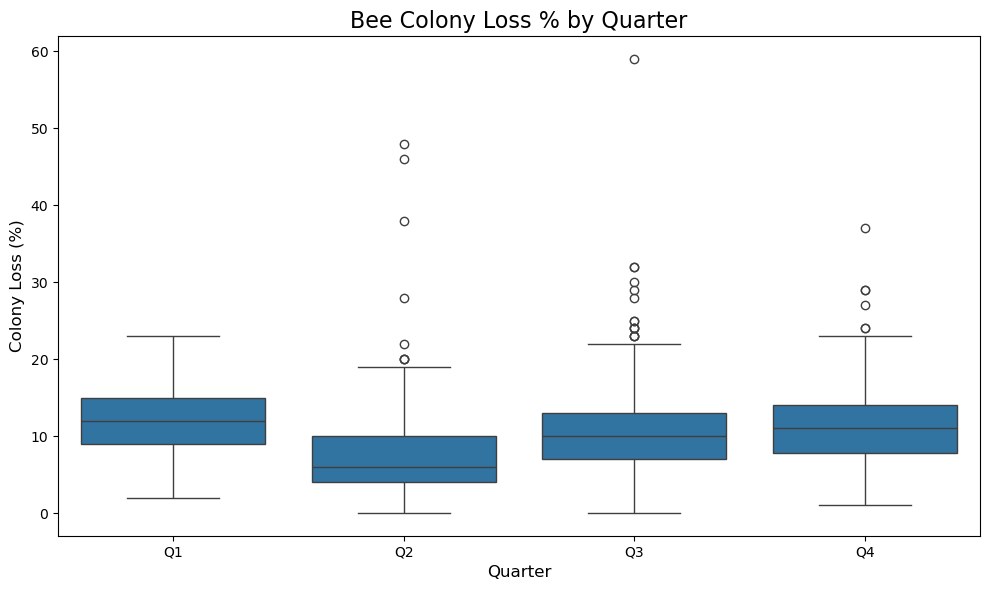

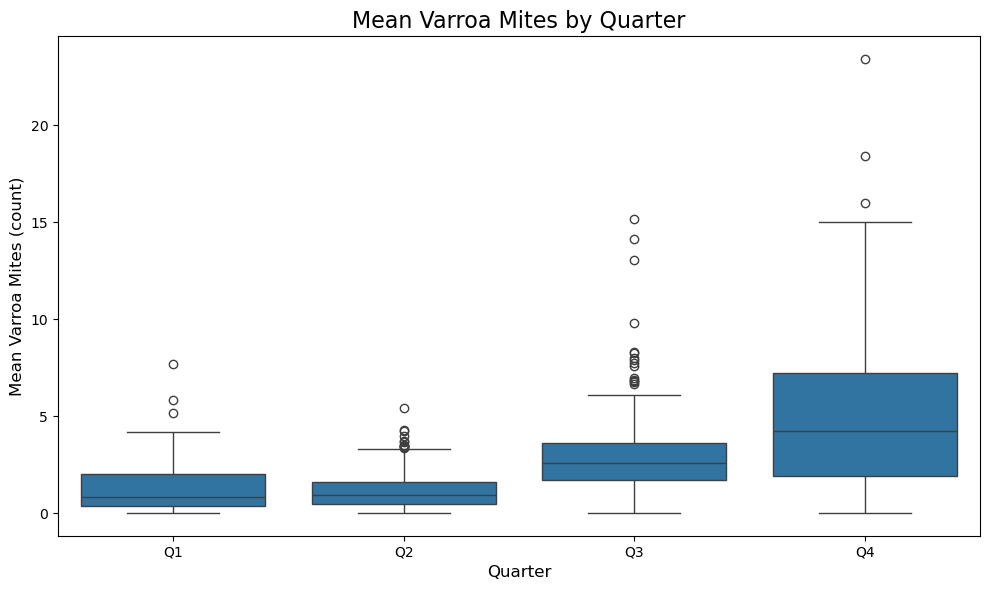

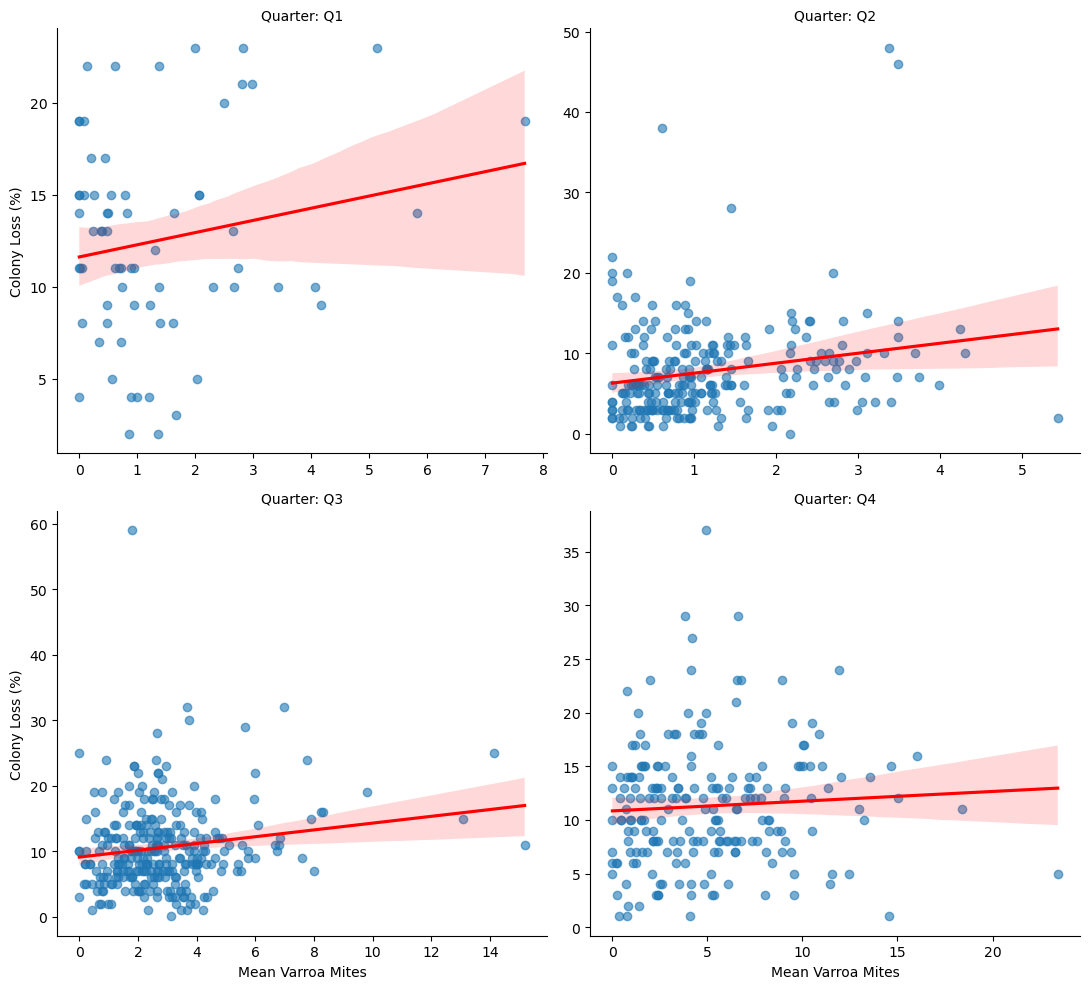

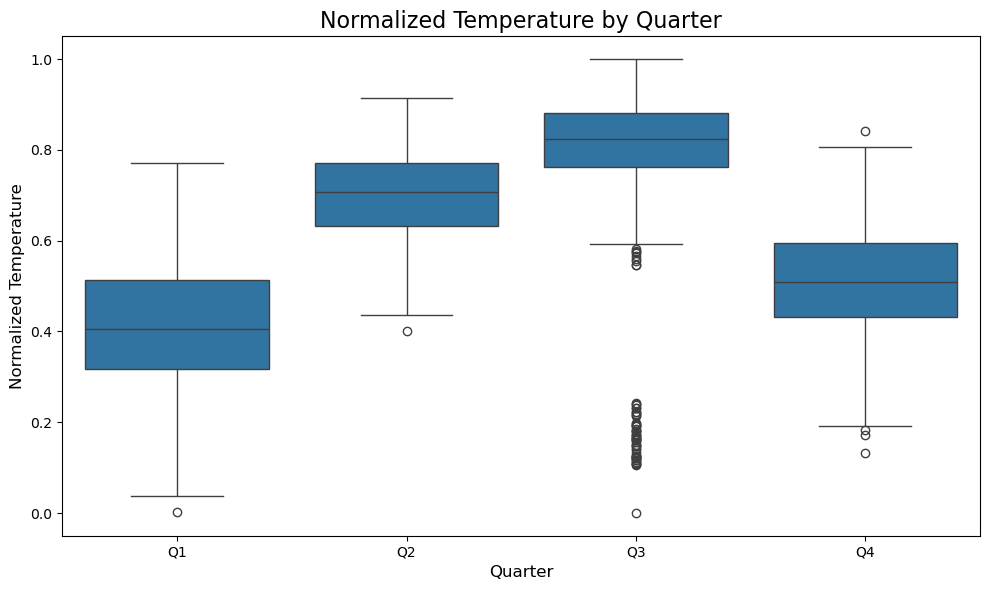

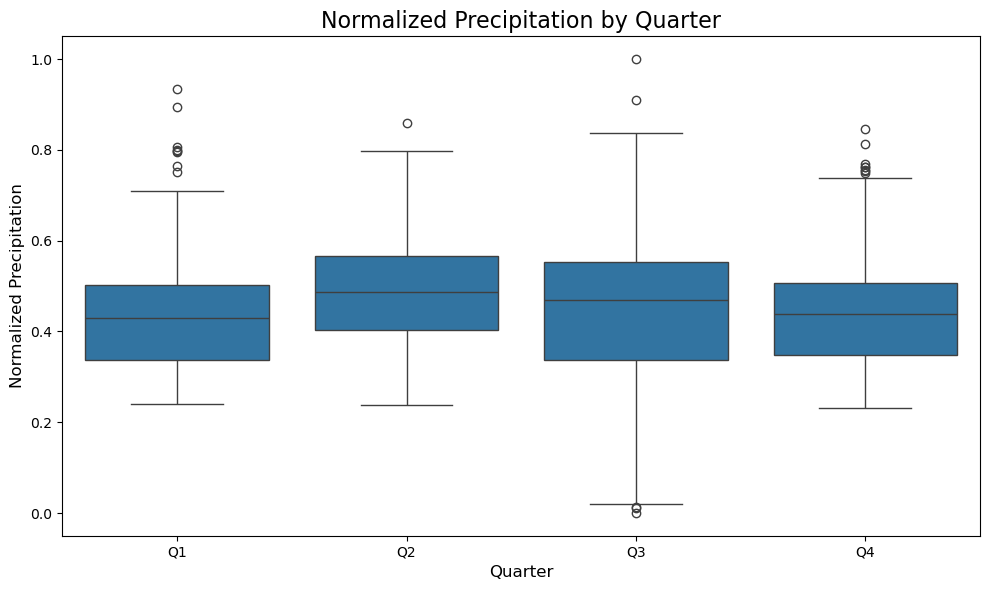

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("Starting quarterly EDA...")

# Resolve repo-relative paths (notebook runs from notebooks/ by default)
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"

# --- Part 1: Analyze Bee Loss and Varroa Mites ---
print("Loading combined bee and varroa data...")

combined_path = INTERIM_DIR / "combined_nass_aphis_weather_1028_df.csv"

try:
    combined_df = pd.read_csv(combined_path)
    print(f"Loaded: {combined_path}")
except FileNotFoundError:
    print(f"Error: '{combined_path}' not found. Check that the file exists in data/interim.")
    raise
except Exception as e:
    print(f"An error occurred loading the file: {e}")
    raise

# Helper to find a column by alternatives
def pick_col(cols, *candidates):
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

# Normalize column names but keep original casing references
cols = list(combined_df.columns)
y_col = pick_col(cols, 'sample_year', 'year', 'Year')
q_col = pick_col(cols, 'quarter', 'Quarter', 'qtr')
s_col = pick_col(cols, 'state_code', 'state', 'State')
v_col = pick_col(cols, 'mean_varroa', 'Mean_Varroa', 'varroa_mean')
# Common variants for loss percent
l_col = pick_col(
    cols,
    'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES',
    'Loss_Pct', 'loss_pct', 'percent_loss', 'loss_rate', 'loss_percent',
    'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES (%)'
)

missing = [name for name, col in [
    ('year', y_col), ('quarter', q_col), ('state', s_col), ('mean_varroa', v_col), ('loss_pct', l_col)
] if col is None]
if missing:
    print("Columns available:", list(combined_df.columns))
    raise KeyError(f"Required columns not found or ambiguous: {missing}")

# Build working DataFrame with consistent names
bee_varroa_df = combined_df[[y_col, q_col, s_col, v_col, l_col]].copy()
bee_varroa_df.rename(columns={
    y_col: 'Year',
    q_col: 'Quarter',
    s_col: 'State',
    v_col: 'Mean_Varroa',
    l_col: 'Loss_Pct',
}, inplace=True)

# Coerce numerics
bee_varroa_df['Mean_Varroa'] = pd.to_numeric(bee_varroa_df['Mean_Varroa'], errors='coerce')
bee_varroa_df['Loss_Pct'] = pd.to_numeric(bee_varroa_df['Loss_Pct'], errors='coerce')

# Normalize Quarter to Q1..Q4
q = bee_varroa_df['Quarter']
if pd.api.types.is_numeric_dtype(q):
    bee_varroa_df['Quarter'] = q.astype('Int64').map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
else:
    # strip and title
    q_norm = q.astype(str).str.strip().str.upper()
    # Handle forms like 1,2,3,4 as strings and 'Q1' etc.
    q_norm = q_norm.replace({'1':'Q1','2':'Q2','3':'Q3','4':'Q4'})
    # Ensure startswith 'Q'
    bee_varroa_df['Quarter'] = np.where(q_norm.str.match(r'^Q[1-4]$'), q_norm, np.nan)

# Drop rows where our key metrics are missing
bee_varroa_df.dropna(subset=['Mean_Varroa', 'Loss_Pct', 'Quarter'], inplace=True)

# Ensure Quarter order is correct for plotting
quarter_order = ['Q1', 'Q2', 'Q3', 'Q4']
bee_varroa_df['Quarter'] = pd.Categorical(bee_varroa_df['Quarter'], categories=quarter_order, ordered=True)

print("Data loaded and cleaned. Generating plots...")

# Plot 1: Bee Loss by Quarter
plt.figure(figsize=(10, 6))
sns.boxplot(x='Quarter', y='Loss_Pct', data=bee_varroa_df)
plt.title('Bee Colony Loss % by Quarter', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Colony Loss (%)', fontsize=12)
plt.tight_layout()
print("Rendered loss_by_quarter figure")

# Plot 2: Mean Varroa by Quarter
plt.figure(figsize=(10, 6))
sns.boxplot(x='Quarter', y='Mean_Varroa', data=bee_varroa_df)
plt.title('Mean Varroa Mites by Quarter', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Mean Varroa Mites (count)', fontsize=12)
plt.tight_layout()
print("Rendered varroa_by_quarter figure")

# Plot 3: Varroa vs. Bee Loss — 2×2 grid by quarter (no savefig)
print("Generating 2×2 grid of Varroa vs. Loss by quarter...")
g = sns.lmplot(
    x='Mean_Varroa', y='Loss_Pct',
    col='Quarter', col_order=quarter_order, col_wrap=2,
    data=bee_varroa_df,
    height=5, aspect=1.1,
    scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'},
    facet_kws={'sharex': False, 'sharey': False, 'despine': True}
)
g.set_axis_labels('Mean Varroa Mites', 'Colony Loss (%)')
g.set_titles(col_template='Quarter: {col_name}')
plt.tight_layout()
print("Rendered 2×2 grid for varroa vs loss")

# --- Part 2: Analyze Weather Data Separately ---
print("\nLoading normalized weather data...")
weather_path = DATA_DIR / 'normalized_weather_data.csv'
try:
    weather_df = pd.read_csv(weather_path)
    print(f"Loaded: {weather_path}")
except FileNotFoundError:
    print(f"Error: '{weather_path}' not found. Skipping weather analysis.")
    weather_df = None  # Continue without weather if not found
except Exception as e:
    print(f"An error occurred loading weather data: {e}")
    weather_df = None

if weather_df is not None:
    # Normalize column names for expected usage
    if 'Quarter' not in weather_df.columns and 'quarter' in weather_df.columns:
        weather_df.rename(columns={'quarter':'Quarter'}, inplace=True)
    # Ensure Quarter order is correct
    weather_df['Quarter'] = weather_df['Quarter'].astype(str).str.strip().str.upper().replace({'1':'Q1','2':'Q2','3':'Q3','4':'Q4'})
    weather_df['Quarter'] = pd.Categorical(weather_df['Quarter'], categories=quarter_order, ordered=True)

    # Plot 4: Normalized Temperature by Quarter (tmpc)
    if {'Quarter','tmpc'}.issubset(weather_df.columns):
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Quarter', y='tmpc', data=weather_df)
        plt.title('Normalized Temperature by Quarter', fontsize=16)
        plt.xlabel('Quarter', fontsize=12)
        plt.ylabel('Normalized Temperature', fontsize=12)
        plt.tight_layout()
        print("Rendered temp_by_quarter figure")
    else:
        print("Skipping temperature plot: columns 'Quarter' and 'tmpc' not both found.")

    # Plot 5: Normalized Precipitation by Quarter (pcpn)
    if {'Quarter','pcpn'}.issubset(weather_df.columns):
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Quarter', y='pcpn', data=weather_df)
        plt.title('Normalized Precipitation by Quarter', fontsize=16)
        plt.xlabel('Quarter', fontsize=12)
        plt.ylabel('Normalized Precipitation', fontsize=12)
        plt.tight_layout()
        print("Rendered precip_by_quarter figure")
    else:
        print("Skipping precipitation plot: columns 'Quarter' and 'pcpn' not both found.")

print("\nEDA complete.")

--- Starting Model A (Explanatory, Same-Quarter) ---
Step 1: Loading and preparing master dataset...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/combined_nass_aphis_weather_1028_df.csv
Step 2: Converting data to numeric...
Step 3: Dropped 115 rows with missing data.
Using 828 complete rows for modeling.
Step 4: Splitting data into Training and Testing sets...
Training set size: 662
Testing set size: 166

Step 5: Training and evaluating models...
--- Training Linear Regression ---
Linear Regression R-squared (R²): 0.052
Linear Regression Mean Absolute Error (MAE): 4.689 percentage points

--- Training Random Forest ---
Random Forest R-squared (R²): 0.025
Random Forest Mean Absolute Error (MAE): 4.718 percentage points

Step 6: Generating Feature Importance plot...

Model Feature Importances:
             Feature  Importance
6        Temperature    0.235803
0        Mean_Varroa    0.202845
5      Precipitation    0.164845
2     DWV_Prevalence

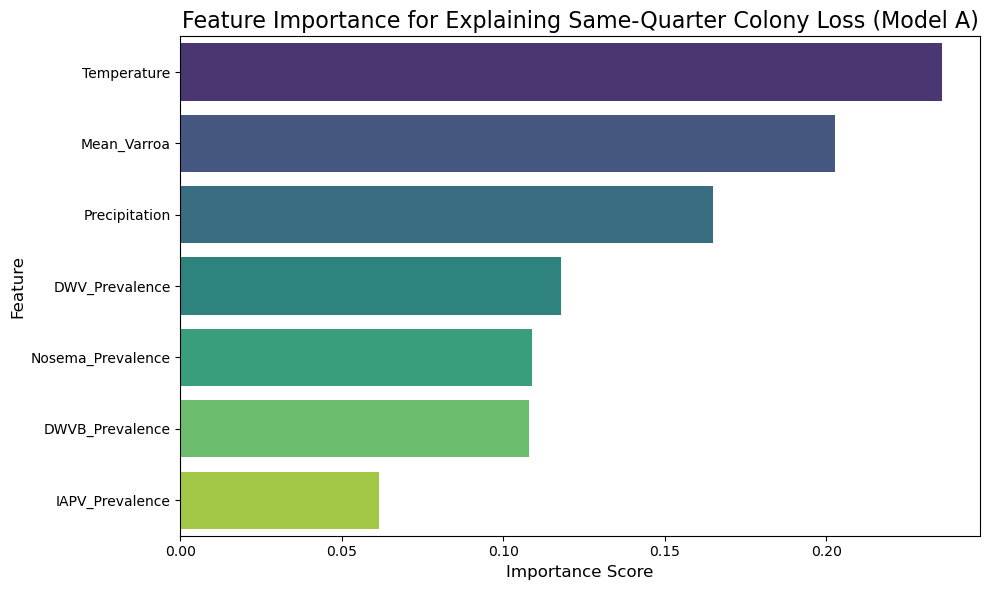


--- Model A (Explanatory) Pipeline Complete ---


In [3]:
#!/usr/bin/env python3
"""
Model A (Explanatory, Same-Quarter)
- Loads combined_nass_aphis_weather_1028_df.csv
- Renames columns for clarity
- Uses same-quarter features to explain Loss_Pct
- Splits data randomly (80/20), trains Linear Regression and Random Forest
- Prints R^2 and MAE; shows feature importance plot inline (no file saved)
"""

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


def _detect_repo_root() -> Path:
    """Best-effort project root detection for notebooks and scripts.
    Preference order:
    1) If running as a script (__file__ defined), go up to repo root.
    2) If running in a notebook, search upward for a folder containing 'data'.
    Fallback to the current working directory.
    """
    # Script mode
    try:
        file_path = Path(__file__).resolve()  # type: ignore[name-defined]
        return file_path.parents[1]
    except NameError:
        pass

    # Notebook/interactive mode
    cwd = Path.cwd()
    candidates = [cwd, *cwd.parents]
    for p in candidates:
        if (p / "data").exists():
            return p
    return cwd


def main() -> int:
    print("--- Starting Model A (Explanatory, Same-Quarter) ---")

    # Step 1: Load and Prepare Data
    print("Step 1: Loading and preparing master dataset...")
    repo_root = _detect_repo_root()
    csv_path = repo_root / "data" / "interim" / "combined_nass_aphis_weather_1028_df.csv"

    try:
        df = pd.read_csv(csv_path)
        print(f"Loaded: {csv_path}")
    except FileNotFoundError:
        print("Error: 'combined_nass_aphis_weather_1028_df.csv' not found in data/interim.")
        return 1
    except Exception as e:
        print(f"An error occurred loading the CSV: {e}")
        return 1

    # Step 2: Data Cleaning and Renaming
    try:
        df = df.rename(
            columns={
                'sample_year': 'Year',
                'quarter': 'Quarter',
                'state_code': 'State',
                'mean_varroa': 'Mean_Varroa',
                'nosema': 'Nosema_Prevalence',
                'dwv': 'DWV_Prevalence',
                'dwvb': 'DWVB_Prevalence',
                'iapv': 'IAPV_Prevalence',
                'pcpn': 'Precipitation',
                'tmpc': 'Temperature',
                'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES': 'Loss_Pct',
            }
        )

        target_col = 'Loss_Pct'
        feature_cols = [
            'Mean_Varroa', 'Nosema_Prevalence', 'DWV_Prevalence',
            'DWVB_Prevalence', 'IAPV_Prevalence', 'Precipitation', 'Temperature'
        ]

        # Keep only needed columns; Year/Quarter/State retained for info/debug
        all_cols = [target_col] + feature_cols + ['Year', 'Quarter', 'State']
        missing = [c for c in all_cols if c not in df.columns]
        if missing:
            # It's okay if Year/Quarter/State are missing for the model itself; we only require features+target
            required = [target_col] + feature_cols
            missing_required = [c for c in required if c not in df.columns]
            if missing_required:
                raise KeyError(f"Missing required columns: {missing_required}")
            # Filter to what exists
            present = [c for c in all_cols if c in df.columns]
            df_clean = df[present].copy()
        else:
            df_clean = df[all_cols].copy()

    except KeyError as e:
        print(f"Error: A required column is missing from the CSV. {e}")
        return 1

    # Step 3: Convert to Numeric
    print("Step 2: Converting data to numeric...")
    for col in [target_col] + feature_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # Step 4: Drop Missing Values
    rows_before = len(df_clean)
    df_clean = df_clean.dropna(subset=[target_col] + feature_cols)
    rows_after = len(df_clean)
    print(f"Step 3: Dropped {rows_before - rows_after} rows with missing data.")
    print(f"Using {rows_after} complete rows for modeling.")

    if rows_after == 0:
        print("Error: No complete data rows remain. Check your source CSV.")
        return 1

    # Step 5: Create X, y, and Split Data
    print("Step 4: Splitting data into Training and Testing sets...")
    X = df_clean[feature_cols]
    y = df_clean[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print(f"Training set size: {len(X_train)}")
    print(f"Testing set size: {len(X_test)}")

    # Step 6: Model Training & Evaluation
    print("\nStep 5: Training and evaluating models...")

    # Model 1: Linear Regression
    print("--- Training Linear Regression ---")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)
    r2_lr = r2_score(y_test, y_pred_lr)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    print(f"Linear Regression R-squared (R²): {r2_lr:.3f}")
    print(f"Linear Regression Mean Absolute Error (MAE): {mae_lr:.3f} percentage points")

    # Model 2: Random Forest Regressor
    print("\n--- Training Random Forest ---")
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    r2_rf = r2_score(y_test, y_pred_rf)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    print(f"Random Forest R-squared (R²): {r2_rf:.3f}")
    print(f"Random Forest Mean Absolute Error (MAE): {mae_rf:.3f} percentage points")

    # Step 7: Feature Importance Plot
    print("\nStep 6: Generating Feature Importance plot...")
    importances = rf_model.feature_importances_
    feature_names = X_train.columns

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print("\nModel Feature Importances:")
    print(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Importance',
        y='Feature',
        data=importance_df,
        palette='viridis',
        hue='Feature',   # Palette warning suppression by providing hue
        legend=False     # Hide legend as hue is only to silence the warning
    )
    plt.title('Feature Importance for Explaining Same-Quarter Colony Loss (Model A)', fontsize=16)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()  # Do not save to disk in the notebook

    print("\n--- Model A (Explanatory) Pipeline Complete ---")
    return 0


# In notebooks, avoid sys.exit to prevent kernel termination
_ = main()


--- Starting Model B (Seasonal Predictive Model with bee_combined_all.csv) ---
Step 1: Loading 'bee_combined_all.csv'...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/processed/bee_combined_all.csv
Step 2: Pivoting data to wide format (index=[state, year], columns=Quarter)...
Step 3: Creating seasonally lagged features and target (Winter Q1 loss)...
Step 4: Cleaning and splitting data...
Dropped 291 rows with missing data (e.g., first year or missing quarters).
Using 197 complete State-Year rows for modeling.
Training set size: 148
Testing set size: 49

Step 5: Training Random Forest model...

--- MODEL B RESULTS ---
Random Forest R-squared (R²): -0.470
Random Forest Mean Absolute Error (MAE): 5.285 percentage points
Random Forest Out-of-Bag (OOB) Score (train): 0.343

Step 6: Generating Feature Importance plot...

Top 15 Most Important Features:
                 Feature  Importance
10         Q_tmin_avg_Q3    0.198453
32     Num_Frost_Days_Q4    0.0

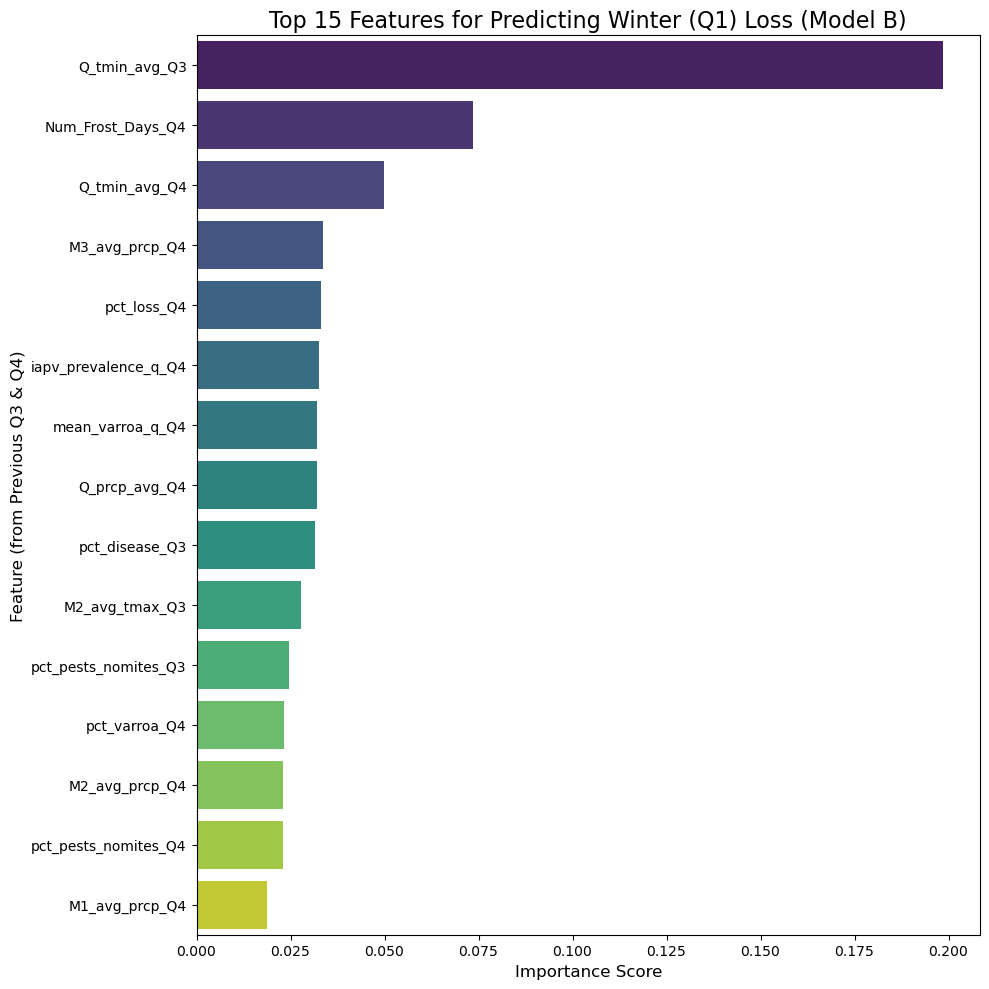

In [ ]:
#!/usr/bin/env python3
"""
Model B (Seasonal Predictive Model)
Hypothesis: Fall (Q3 & Q4) pest/pathogen/weather features predict next year's Winter (Q1) loss.
Data source: data/processed/bee_combined_all.csv
"""

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


def _detect_repo_root() -> Path:
    """Return repo root when running from notebook or script.
    Looks upward for a 'data' folder; falls back to cwd.
    """
    try:
        file_path = Path(__file__).resolve()  # type: ignore[name-defined]
        return file_path.parents[1]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / "data").exists():
            return p
    return cwd


def _pick_col(cols: list[str], *candidates: str) -> str | None:
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


print("--- Starting Model B (Seasonal Predictive Model with bee_combined_all.csv) ---")

# --- Step 1: Load and Prepare Data ---
print("Step 1: Loading 'bee_combined_all.csv'...")
repo_root = _detect_repo_root()
csv_path = repo_root / 'data' / 'processed' / 'bee_combined_all.csv'
try:
    df = pd.read_csv(csv_path)
    print(f"Loaded: {csv_path}")
except FileNotFoundError:
    print("Error: 'bee_combined_all.csv' not found at expected path.")
    raise
except Exception as e:
    print(f"An error occurred: {e}")
    raise

# Identify ID columns robustly
cols = list(df.columns)
year_col = _pick_col(cols, 'year', 'sample_year', 'Year')
qtr_col = _pick_col(cols, 'quarter', 'Quarter', 'qtr')
state_col = _pick_col(cols, 'state_code', 'state', 'State', 'state_fips')

missing_ids = [name for name, col in [('year', year_col), ('quarter', qtr_col), ('state_code', state_col)] if col is None]
if missing_ids:
    print('Columns available:', list(df.columns))
    raise KeyError(f"Required id columns not found or ambiguous: {missing_ids}")

# --- Step 2: Define Feature and Target Columns ---
# Declare a broad set of potential columns, filtered to those that actually exist
value_candidates = [
    # Targets and loss components
    'pct_loss', 'pct_disease', 'pct_other', 'pct_pesticides', 'pct_pests_nomites', 'pct_unknown', 'pct_varroa',
    # Varroa & pathogens
    'mean_varroa_q', 'mean_spores_q',
    'abpv_prevalence_q', 'cbpv_prevalence_q', 'dwv_prevalence_q', 'iapv_prevalence_q', 'kbv_prevalence_q', 'lsv2_prevalence_q',
    # Quarterly weather (common naming variants)
    'Q_prcp_avg', 'Q_pcpn_avg', 'Q_tmax_avg', 'Q_tmin_avg', 'Q_tmpc_avg', 'Q_pdsis_avg', 'Q_zndx_avg',
    # Monthly-aggregate weather carried on quarter rows (if present)
    'M1_avg_prcp', 'M2_avg_prcp', 'M3_avg_prcp',
    'M1_avg_tmax', 'M2_avg_tmax', 'M3_avg_tmax',
    # Event counts
    'Num_Heat_Stress_Days', 'Num_Frost_Days'
]

# Add any other pathogen prevalence columns that match the pattern '*_prevalence_q'
value_candidates += [c for c in cols if c.endswith('_prevalence_q') and c not in value_candidates]

# Keep only the columns that exist
value_cols = [c for c in value_candidates if c in df.columns]

# Build working DataFrame
use_cols = [year_col, qtr_col, state_col] + value_cols
df_use = df[use_cols].copy()

# Normalize quarter values to 'Q1'..'Q4'
q = df_use[qtr_col]
if pd.api.types.is_numeric_dtype(q):
    df_use['QuarterNorm'] = q.astype('Int64').map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
else:
    q_norm = q.astype(str).str.strip().str.upper()
    q_norm = q_norm.replace({'1':'Q1','2':'Q2','3':'Q3','4':'Q4'})
    df_use['QuarterNorm'] = np.where(q_norm.str.match(r'^Q[1-4]$'), q_norm, np.nan)

# Coerce all value columns to numeric
for c in value_cols:
    df_use[c] = pd.to_numeric(df_use[c], errors='coerce')

print("Step 2: Pivoting data to wide format (index=[state, year], columns=Quarter)...")
# --- Step 3 & 4: Pivot Data & Flatten Columns ---
df_wide = df_use.pivot_table(
    index=[state_col, year_col],
    columns='QuarterNorm',
    values=value_cols,
    aggfunc='mean'  # handle potential duplicate rows conservatively
)

# If there are no columns after pivot (e.g., quarter missing), bail out
if df_wide.empty or len(df_wide.columns) == 0:
    raise ValueError("Pivot produced no columns; check that quarter values exist and value columns are present.")

# Flatten MultiIndex columns: (val, Qn) -> f"{val}_{Qn}"
df_wide.columns = [f"{val}_{q}" for (val, q) in df_wide.columns.to_list()]

df_wide = df_wide.reset_index().rename(columns={state_col: 'state_code', year_col: 'year'})

# Ensure deterministic ordering for lagging
df_wide.sort_values(['state_code', 'year'], inplace=True)

# --- Step 5: Create Target (y) ---
print("Step 3: Creating seasonally lagged features and target (Winter Q1 loss)...")
if 'pct_loss_Q1' not in df_wide.columns:
    raise KeyError("'pct_loss_Q1' column not found after pivoting. Check for missing Q1 data in the source file.")

y = df_wide['pct_loss_Q1']

# --- Step 6: Create Features (X) from Q3 & Q4 ---
feature_cols_q3 = [c for c in df_wide.columns if c.endswith('_Q3')]
feature_cols_q4 = [c for c in df_wide.columns if c.endswith('_Q4')]
X_cols = feature_cols_q3 + feature_cols_q4

if not X_cols:
    raise KeyError("No Q3 or Q4 feature columns found after pivoting. Check that value columns exist for these quarters.")

# --- Step 7: Apply Lag (grouped by state) ---
X_unlagged = df_wide[X_cols].copy()
X = X_unlagged.groupby(df_wide['state_code']).shift(1)  # align prior year's fall with current winter

# Add identifiers for context/splitting
X['year'] = df_wide['year']
X['state_code'] = df_wide['state_code']

# --- Step 8: Clean the Data ---
print("Step 4: Cleaning and splitting data...")
model_df = pd.concat([X, y.rename('pct_loss_Q1')], axis=1)
rows_before = len(model_df)
model_df = model_df.dropna()
rows_after = len(model_df)
print(f"Dropped {rows_before - rows_after} rows with missing data (e.g., first year or missing quarters).")
print(f"Using {rows_after} complete State-Year rows for modeling.")

if rows_after == 0:
    raise ValueError("No complete rows remain after lagging and cleaning. Ensure sufficient contiguous yearly data per state.")

# --- Step 9: Time-Based Split ---
TEST_YEAR_START = 2023
train_df = model_df[model_df['year'] < TEST_YEAR_START]
test_df = model_df[model_df['year'] >= TEST_YEAR_START]

feature_names = [c for c in X.columns if c not in ['year', 'state_code']]
X_train = train_df[feature_names]
y_train = train_df['pct_loss_Q1']
X_test = test_df[feature_names]
y_test = test_df['pct_loss_Q1']

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError("Training or testing set is empty. Not enough data for the specified time split.")

# --- Step 10: Train & Evaluate ---
print("\nStep 5: Training Random Forest model...")
rf_model = RandomForestRegressor(n_estimators=300, random_state=42, oob_score=True, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\n--- MODEL B RESULTS ---")
print(f"Random Forest R-squared (R²): {r2_rf:.3f}")
print(f"Random Forest Mean Absolute Error (MAE): {mae_rf:.3f} percentage points")
print(f"Random Forest Out-of-Bag (OOB) Score (train): {rf_model.oob_score_:.3f}")

# --- Step 11: Plot Importance ---
print("\nStep 6: Generating Feature Importance plot...")
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15))

plt.figure(figsize=(10, 10))
sns.barplot(
    x='Importance', y='Feature', data=importance_df.head(15),
    palette='viridis', hue='Feature', legend=False
)
plt.title('Top 15 Features for Predicting Winter (Q1) Loss (Model B)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature (from Previous Q3 & Q4)', fontsize=12)
plt.tight_layout()

#out_png = repo_root / 'feature_importance_seasonal_model.png'
#plt.savefig(out_png)
#print(f"Saved {out_png}")

print("\n--- Model B (Seasonal Predictive) Pipeline Complete ---")


--- Starting Model C (Tuned Seasonal Model with Curated Features) ---
Step 1: Loading 'bee_combined_all.csv'...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/processed/bee_combined_all.csv
Step 2: Pivoting data with curated features to wide format...
Step 3: Building lagged features and target...
Step 4: Cleaning and splitting data...
Dropped 291 rows with missing data.
Using 197 complete State-Year rows for modeling.
Training set size: 148
Testing set size: 49

Step 5: Training tuned Random Forest (depth=5, leaf=5)...

--- MODEL C (TUNED) RESULTS ---
Random Forest R-squared (R²): -0.742
Random Forest Mean Absolute Error (MAE): 5.593 percentage points
Random Forest Out-of-Bag (OOB) Score (train): 0.338

Step 6: Generating Feature Importance plot...

Top 10 Most Important Features (Tuned Model):
                Feature  Importance
4         Q_tmin_avg_Q3    0.326124
8     Num_Frost_Days_Q4    0.117146
12        Q_tmin_avg_Q4    0.099890
14     mean_va

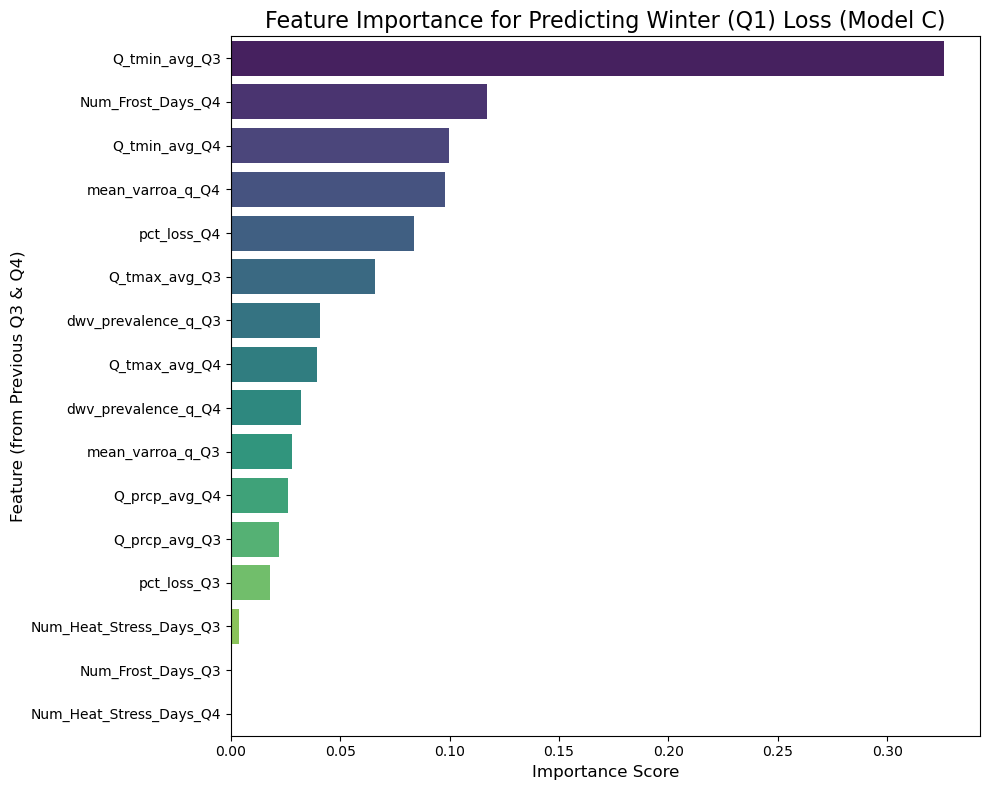

In [ ]:
#!/usr/bin/env python3
"""
Model C (Tuned Seasonal Model with Curated Features)
Goal: Predict Winter (Q1) Loss using previous Fall (Q3 & Q4) curated features
Data source: data/processed/bee_combined_all.csv
"""

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


def _detect_repo_root() -> Path:
    """Return repo root when running from notebook or script.
    Looks upward for a 'data' folder; falls back to cwd.
    """
    try:
        file_path = Path(__file__).resolve()  # type: ignore[name-defined]
        return file_path.parents[1]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / "data").exists():
            return p
    return cwd


def _pick_col(cols: list[str], *candidates: str) -> str | None:
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


print("--- Starting Model C (Tuned Seasonal Model with Curated Features) ---")

# --- Step 1: Load Data ---
print("Step 1: Loading 'bee_combined_all.csv'...")
repo_root = _detect_repo_root()
csv_path = repo_root / 'data' / 'processed' / 'bee_combined_all.csv'
try:
    df = pd.read_csv(csv_path)
    print(f"Loaded: {csv_path}")
except FileNotFoundError:
    raise FileNotFoundError("'bee_combined_all.csv' not found at expected path.")
except Exception as e:
    raise RuntimeError(f"An error occurred loading the CSV: {e}")

# Identify robust ID columns
cols = list(df.columns)
year_col = _pick_col(cols, 'year', 'sample_year', 'Year')
qtr_col = _pick_col(cols, 'quarter', 'Quarter', 'qtr')
state_col = _pick_col(cols, 'state_code', 'state', 'State', 'state_fips')

missing_ids = [name for name, col in [('year', year_col), ('quarter', qtr_col), ('state_code', state_col)] if col is None]
if missing_ids:
    print('Columns available:', list(df.columns))
    raise KeyError(f"Required id columns not found or ambiguous: {missing_ids}")

# --- Step 2: Define Curated Feature List ---
value_cols_curated = [
    'pct_loss',             # Target (Q1)
    'mean_varroa_q',        # Key pest
    'dwv_prevalence_q',     # Key virus
    'Q_prcp_avg',           # Quarterly precipitation
    'Q_tmax_avg',           # Quarterly max temp
    'Q_tmin_avg',           # Quarterly min temp
    'Num_Heat_Stress_Days', # Weather extreme
    'Num_Frost_Days'        # Weather extreme
]

# Keep only curated columns that exist
value_cols = [c for c in value_cols_curated if c in df.columns]
if 'pct_loss' not in value_cols:
    raise KeyError("'pct_loss' not found in dataset; required for target.")

# Build working DataFrame
use_cols = [year_col, qtr_col, state_col] + value_cols
df_use = df[use_cols].copy()

# Normalize quarter values to 'Q1'..'Q4'
q = df_use[qtr_col]
if pd.api.types.is_numeric_dtype(q):
    df_use['QuarterNorm'] = q.astype('Int64').map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
else:
    q_norm = q.astype(str).str.strip().str.upper()
    q_norm = q_norm.replace({'1':'Q1','2':'Q2','3':'Q3','4':'Q4'})
    df_use['QuarterNorm'] = np.where(q_norm.str.match(r'^Q[1-4]$'), q_norm, np.nan)

# Convert all value columns to numeric
for c in value_cols:
    df_use[c] = pd.to_numeric(df_use[c], errors='coerce')

print("Step 2: Pivoting data with curated features to wide format...")
# --- Step 3 & 4: Pivot Data & Flatten Columns ---
df_wide = df_use.pivot_table(
    index=[state_col, year_col],
    columns='QuarterNorm',
    values=value_cols,
    aggfunc='mean'
)

if df_wide.empty or len(df_wide.columns) == 0:
    raise ValueError("Pivot produced no columns; check quarter values and curated features.")

# Flatten MultiIndex columns: (val, Qn) -> val_Qn
df_wide.columns = [f"{val}_{q}" for (val, q) in df_wide.columns.to_list()]
df_wide = df_wide.reset_index().rename(columns={state_col: 'state_code', year_col: 'year'})

# Sort for deterministic lagging
df_wide.sort_values(['state_code', 'year'], inplace=True)

# --- Step 5: Create Target (y) ---
print("Step 3: Building lagged features and target...")
if 'pct_loss_Q1' not in df_wide.columns:
    raise KeyError("'pct_loss_Q1' not found after pivoting. Ensure Q1 data exists.")

y = df_wide['pct_loss_Q1']

# --- Step 6: Feature set: only curated Q3 & Q4 ---
feature_cols_q3 = [c for c in df_wide.columns if c.endswith('_Q3')]
feature_cols_q4 = [c for c in df_wide.columns if c.endswith('_Q4')]
X_cols = [c for c in feature_cols_q3 + feature_cols_q4 if any(c.startswith(prefix) for prefix in [
    'mean_varroa_q_', 'dwv_prevalence_q_', 'Q_prcp_avg_', 'Q_tmax_avg_', 'Q_tmin_avg_', 'Num_Heat_Stress_Days_', 'Num_Frost_Days_', 'pct_loss_'
])]

if not X_cols:
    raise KeyError("No curated Q3/Q4 feature columns found after pivoting.")

# --- Step 7: Apply Lag (per state) ---
X_unlagged = df_wide[X_cols].copy()
X = X_unlagged.groupby(df_wide['state_code']).shift(1)

# Add IDs for splitting
X['year'] = df_wide['year']
X['state_code'] = df_wide['state_code']

# --- Step 8: Clean & Split ---
print("Step 4: Cleaning and splitting data...")
model_df = pd.concat([X, y.rename('pct_loss_Q1')], axis=1)
rows_before = len(model_df)
model_df = model_df.dropna()
rows_after = len(model_df)
print(f"Dropped {rows_before - rows_after} rows with missing data.")
print(f"Using {rows_after} complete State-Year rows for modeling.")

if rows_after == 0:
    raise ValueError("No complete rows after lagging and cleaning.")

TEST_YEAR_START = 2023
train_df = model_df[model_df['year'] < TEST_YEAR_START]
test_df = model_df[model_df['year'] >= TEST_YEAR_START]

feature_names = [c for c in X.columns if c not in ['year', 'state_code']]
X_train = train_df[feature_names]
y_train = train_df['pct_loss_Q1']
X_test = test_df[feature_names]
y_test = test_df['pct_loss_Q1']

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError("Training or testing set is empty; adjust split or ensure data coverage.")

# --- Step 9: Train Tuned Model ---
print("\nStep 5: Training tuned Random Forest (depth=5, leaf=5)...")
rf_model_tuned = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    max_depth=5,
    min_samples_leaf=5,
    n_jobs=-1,
)
rf_model_tuned.fit(X_train, y_train)

# --- Step 10: Evaluate ---
y_pred = rf_model_tuned.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("\n--- MODEL C (TUNED) RESULTS ---")
print(f"Random Forest R-squared (R²): {r2:.3f}")
print(f"Random Forest Mean Absolute Error (MAE): {mae:.3f} percentage points")
print(f"Random Forest Out-of-Bag (OOB) Score (train): {rf_model_tuned.oob_score_:.3f}")

# --- Step 11: Plot Importance ---
print("\nStep 6: Generating Feature Importance plot...")
importances = rf_model_tuned.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Most Important Features (Tuned Model):")
print(importance_df.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', y='Feature', data=importance_df,
    palette='viridis', hue='Feature', legend=False
)
plt.title('Feature Importance for Predicting Winter (Q1) Loss (Model C)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature (from Previous Q3 & Q4)', fontsize=12)
plt.tight_layout()

out_png = repo_root / 'feature_importance_seasonal_model_C.png'
#plt.savefig(out_png)
#print(f"Saved {out_png}")

print("\n--- Model C (Tuned Seasonal) Pipeline Complete ---")


--- Starting Model D (Fall Aggregate Model) ---
Step 1: Loading 'bee_combined_all.csv'...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/processed/bee_combined_all.csv
Step 2: Pivoting data to 'wide' format...
Step 3: Engineering 'Fall Aggregate' features (avg of Q3 & Q4)...
Created 7 Fall aggregate features.
Step 5: Cleaning and splitting data...
Dropped 181 rows with missing data.
Using 307 complete State-Year rows for modeling.
Training set size: 225
Testing set size: 82

Step 6: Training Aggressively Tuned Random Forest (Model D)...

--- MODEL D (FALL AGGREGATE) RESULTS ---
Random Forest R-squared (R²): -0.312
Random Forest Mean Absolute Error (MAE): 6.635 percentage points

Step 7: Generating Feature Importance plot...

Model D Feature Importances (Top 15):
                     Feature  Importance
4            Fall_Q_tmin_avg    0.523634
3            Fall_Q_tmax_avg    0.209024
2            Fall_Q_prcp_avg    0.093884
6        Fall_Num_Frost_Days

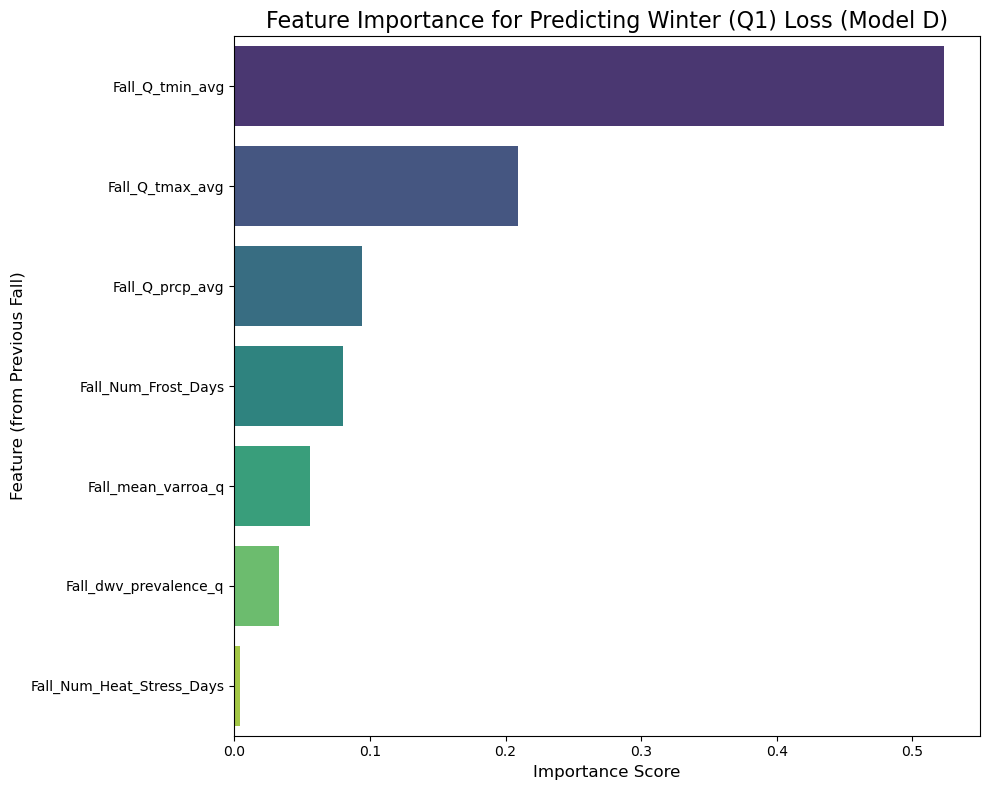

In [ ]:
#!/usr/bin/env python3
"""
Model D (Fall Aggregate Model)
Goal: Predict Winter (Q1) Loss using previous Fall (Q3 & Q4) aggregated features.
Data source: data/processed/bee_combined_all.csv
"""

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


def _detect_repo_root() -> Path:
    """Return repo root when running from notebook or script.
    Looks upward for a 'data' folder; falls back to cwd.
    """
    try:
        file_path = Path(__file__).resolve()  # type: ignore[name-defined]
        return file_path.parents[1]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / "data").exists():
            return p
    return cwd


def _pick_col(cols: list[str], *candidates: str) -> str | None:
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


print("--- Starting Model D (Fall Aggregate Model) ---")

# --- Step 1: Load Data ---
print("Step 1: Loading 'bee_combined_all.csv'...")
repo_root = _detect_repo_root()
csv_path = repo_root / 'data' / 'processed' / 'bee_combined_all.csv'
try:
    df = pd.read_csv(csv_path)
    print(f"Loaded: {csv_path}")
except FileNotFoundError:
    print("Error: 'bee_combined_all.csv' not found at expected path.")
    raise

# Identify robust ID columns
cols = list(df.columns)
year_col = _pick_col(cols, 'year', 'sample_year', 'Year')
qtr_col = _pick_col(cols, 'quarter', 'Quarter', 'qtr')
state_col = _pick_col(cols, 'state_code', 'state', 'State', 'state_fips')

missing_ids = [name for name, col in [('year', year_col), ('quarter', qtr_col), ('state_code', state_col)] if col is None]
if missing_ids:
    print('Columns available:', list(df.columns))
    raise KeyError(f"Required id columns not found or ambiguous: {missing_ids}")

# --- Step 2: Define Curated Feature List ---
feature_cols_curated = [
    'mean_varroa_q',        # Key pest
    'dwv_prevalence_q',     # Key virus
    'Q_prcp_avg',           # Quarterly avg precipitation
    'Q_tmax_avg',           # Quarterly avg max temp
    'Q_tmin_avg',           # Quarterly avg min temp
    'Num_Heat_Stress_Days', # Weather extreme
    'Num_Frost_Days'        # Weather extreme
]

target_col = 'pct_loss'  # Our target

# Keep only curated features that exist
feature_cols = [c for c in feature_cols_curated if c in df.columns]
if not feature_cols:
    raise KeyError("None of the curated feature columns were found in the dataset.")

# Build working DataFrame
use_cols = [year_col, qtr_col, state_col] + feature_cols + ([target_col] if target_col in df.columns else [])
df_use = df[use_cols].copy()

# Normalize quarter values to 'Q1'..'Q4'
q = df_use[qtr_col]
if pd.api.types.is_numeric_dtype(q):
    df_use['QuarterNorm'] = q.astype('Int64').map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
else:
    q_norm = q.astype(str).str.strip().str.upper()
    q_norm = q_norm.replace({'1':'Q1','2':'Q2','3':'Q3','4':'Q4'})
    df_use['QuarterNorm'] = np.where(q_norm.str.match(r'^Q[1-4]$'), q_norm, np.nan)

# Convert values to numeric
for c in feature_cols + ([target_col] if target_col in df_use.columns else []):
    df_use[c] = pd.to_numeric(df_use[c], errors='coerce')

print("Step 2: Pivoting data to 'wide' format...")
# --- Step 3: Pivot Data ---
pivot_values = feature_cols + ([target_col] if target_col in df_use.columns else [])
df_wide = df_use.pivot_table(
    index=[state_col, year_col],
    columns='QuarterNorm',
    values=pivot_values,
    aggfunc='mean'
)

if df_wide.empty or len(df_wide.columns) == 0:
    raise ValueError("Pivot produced no columns; check quarter values and curated features.")

# Flatten MultiIndex columns: (val, Qn) -> f"{val}_{Qn}"
df_wide.columns = [f"{val}_{q}" for (val, q) in df_wide.columns.to_list()]
df_wide = df_wide.reset_index().rename(columns={state_col: 'state_code', year_col: 'year'})

# --- Step 4: Create Fall Aggregate Features ---
print("Step 3: Engineering 'Fall Aggregate' features (avg of Q3 & Q4)...")
X_fall = pd.DataFrame(index=df_wide.index)
new_feature_names: list[str] = []
for base_feature in feature_cols:
    q3_col = f'{base_feature}_Q3'
    q4_col = f'{base_feature}_Q4'
    fall_col = f'Fall_{base_feature}'
    if q3_col in df_wide.columns and q4_col in df_wide.columns:
        X_fall[fall_col] = df_wide[[q3_col, q4_col]].mean(axis=1, skipna=True)
        new_feature_names.append(fall_col)

print(f"Created {len(new_feature_names)} Fall aggregate features.")
if not new_feature_names:
    raise ValueError("No Fall aggregate features could be created (missing Q3/Q4 pairs).")

# --- Step 5: Create Target (y) ---
if 'pct_loss_Q1' not in df_wide.columns:
    raise KeyError("'pct_loss_Q1' column not found. Check for missing Q1 data.")

y = df_wide['pct_loss_Q1']

# --- Step 6 & 7: Lag features (per state) and add IDs ---
X = X_fall.groupby(df_wide['state_code']).shift(1)  # align prior year's fall with current winter
X['year'] = df_wide['year']
X['state_code'] = df_wide['state_code']

# --- Step 8: Clean & Split ---
print("Step 5: Cleaning and splitting data...")
model_df = pd.concat([X, y.rename('pct_loss_Q1')], axis=1)
rows_before = len(model_df)
model_df = model_df.dropna()
rows_after = len(model_df)
print(f"Dropped {rows_before - rows_after} rows with missing data.")
print(f"Using {rows_after} complete State-Year rows for modeling.")

if rows_after == 0:
    raise ValueError("No complete data rows remain. Check source data.")

TEST_YEAR_START = 2023
train_df = model_df[model_df['year'] < TEST_YEAR_START]
test_df = model_df[model_df['year'] >= TEST_YEAR_START]

X_train = train_df[new_feature_names]
y_train = train_df['pct_loss_Q1']
X_test = test_df[new_feature_names]
y_test = test_df['pct_loss_Q1']

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError("Training or testing set is empty.")

# --- Step 9: Train & Evaluate ---
print("\nStep 6: Training Aggressively Tuned Random Forest (Model D)...")
rf_model_tuned = RandomForestRegressor(
    random_state=42,
    max_depth=4,
    min_samples_leaf=10,
    n_estimators=200,
    n_jobs=-1,
)
rf_model_tuned.fit(X_train, y_train)

y_pred = rf_model_tuned.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n--- MODEL D (FALL AGGREGATE) RESULTS ---")
print(f"Random Forest R-squared (R²): {r2:.3f}")
print(f"Random Forest Mean Absolute Error (MAE): {mae:.3f} percentage points")

# --- Step 11: Plot Importance ---
print("\nStep 7: Generating Feature Importance plot...")
importances = rf_model_tuned.feature_importances_
importance_df = pd.DataFrame({'Feature': new_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nModel D Feature Importances (Top 15):")
print(importance_df.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance for Predicting Winter (Q1) Loss (Model D)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature (from Previous Fall)', fontsize=12)
plt.tight_layout()

out_png = repo_root / 'feature_importance_seasonal_model_D.png'
#plt.savefig(out_png)
#print(f"Saved {out_png}")

print("\n--- Model D (Fall Aggregate) Pipeline Complete ---")
